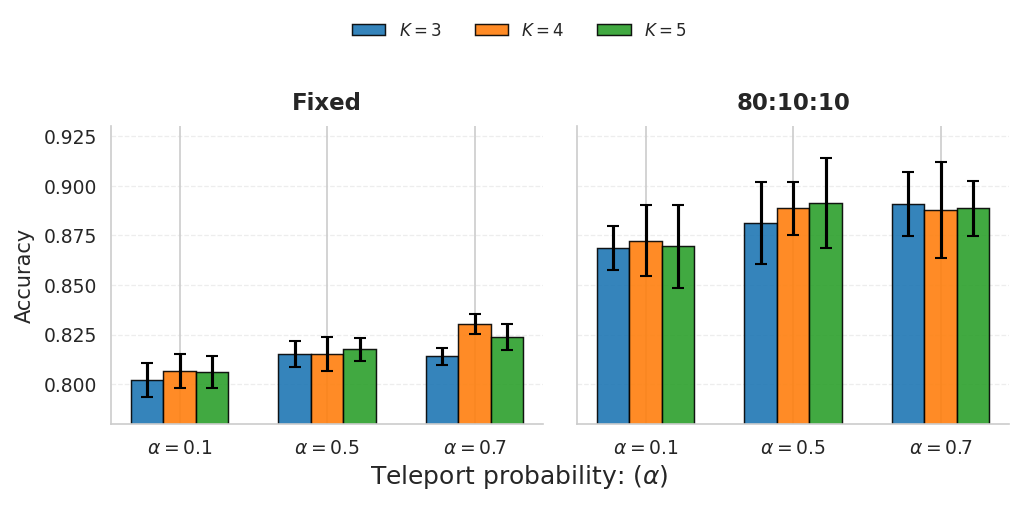

In [12]:
##mmm
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CORA ONLY
# ============================================================

alphas = [0.1, 0.5, 0.7]
Ks = [3, 4, 5]

cora = {
    "Fixed": {
        0.1: {
            3: (0.8020, 0.0087),
            4: (0.8066, 0.0085),
            5: (0.8062, 0.0081)
        },
        0.5: {
            3: (0.8150, 0.0066),
            4: (0.8154, 0.0086),
            5: (0.8176, 0.0058)
        },
        0.7: {
            3: (0.8140, 0.0043),
            4: (0.8302, 0.0050),
            5: (0.8236, 0.0065)
        }
    },

    "80:10:10": {
        0.1: {
            3: (0.8686, 0.0113),
            4: (0.8723, 0.0179),
            5: (0.8694, 0.0211)
        },
        0.5: {
            3: (0.8812, 0.0207),
            4: (0.8886, 0.0133),
            5: (0.8915, 0.0227)
        },
        0.7: {
            3: (0.8908, 0.0163),
            4: (0.8878, 0.0244),
            5: (0.8886, 0.0139)
        }
    }
}


# ============================================================
# PUBLICATION STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(6.8, 3.2),
    sharey=True
)

x = np.arange(len(alphas))
width = 0.22


# ============================================================
# TWO SPLITS
# ============================================================

for ax, split in zip(
    axes,
    ["Fixed", "80:10:10"]
):

    for k_idx, K in enumerate(Ks):

        means = [
            cora[split][alpha][K][0]
            for alpha in alphas
        ]

        stds = [
            cora[split][alpha][K][1]
            for alpha in alphas
        ]

        positions = (
            x + (k_idx - 1) * width
        )

        ax.bar(
            positions,
            means,
            width=width,
            yerr=stds,
            capsize=3,
            label=f"$K={K}$",
            edgecolor="black",
            linewidth=0.7,
            alpha=0.9
        )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        split,
        fontweight="bold",
        pad=8
    )

    # --------------------------------------------------------
    # X axis
    # --------------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        [f"$\\alpha={a}$" for a in alphas]
    )

    # --------------------------------------------------------
    # Y axis
    # --------------------------------------------------------

    ax.set_ylim(0.78, 0.93)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    ax.set_axisbelow(True)

    # Clean frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ============================================================
# LABELS
# ============================================================

axes[0].set_ylabel("Accuracy")

fig.supxlabel(
    r"Teleport probability: ($\alpha$)",
    y=0.02
)


# ============================================================
# LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03)
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.16,
    top=0.78,
    wspace=0.08
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "cora_barplot.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "cora_barplot.png",
    bbox_inches="tight"
)

plt.show()